# Laboratorio 5: Modelos de clasificación

Se utiliza `train_clean.csv`, generado en el notebook 01.

**Este notebook cubre:**
- Punto 6: Múltiples modelos de clasificación, búsqueda de hiperparámetros, comparación de métricas y selección del mejor modelo.

Al final del notebook se guarda el mejor modelo entrenado (`best_model.pkl`) y el vectorizador (`tfidf_vectorizer.pkl`) para ser reutilizados en los notebooks 05 (función de clasificación) y 06 (análisis de sentimientos y reentrenamiento).

---

In [1]:
import warnings
warnings.filterwarnings("ignore")
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)

pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 1. Carga del dataset preprocesado

In [2]:
df = pd.read_csv("./data/train_clean.csv")
df["clean_text"] = df["clean_text"].fillna("")

print(f"Total de tweets: {len(df):,}")
df.head(3)

Total de tweets: 7,613


,id,keyword,location,text,clean_text,n_caracteres,n_palabras,clean_n_palabras,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,deeds reason earthquake may allah forgive us,69,13,7,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada,38,7,7,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place or...,residents asked shelter place notified officers evacuation shelter place orders expected,133,22,11,1


## 2. División train/test (Punto 6)

Se separa el 80% para entrenamiento y 20% para prueba, de forma estratificada por `target` para conservar la proporción de clases en ambos subconjuntos.

In [3]:
X = df["clean_text"]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Entrenamiento: {len(X_train):,} tweets  |  Prueba: {len(X_test):,} tweets")
print("Proporción clase 1 en train:", round(y_train.mean(), 3))
print("Proporción clase 1 en test :", round(y_test.mean(), 3))

Entrenamiento: 6,090 tweets  |  Prueba: 1,523 tweets
Proporción clase 1 en train: 0.43
Proporción clase 1 en test : 0.429


## 3. Vectorización TF-IDF (Punto 6)

Se usa `TfidfVectorizer` con `ngram_range=(1, 2)` (unigramas + bigramas), tal como se concluyó en el notebook 02.

In [4]:
vectorizador_tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=15000)

X_train_tfidf = vectorizador_tfidf.fit_transform(X_train)
X_test_tfidf = vectorizador_tfidf.transform(X_test)

print("Dimensiones de la matriz TF-IDF de entrenamiento:", X_train_tfidf.shape)

Dimensiones de la matriz TF-IDF de entrenamiento: (6090, 9232)


## 4. Comparación de modelos base (Punto 6)

Se entrenan cuatro algoritmos como baseline antes de ajustar hiperparámetros:
- **Multinomial Naive Bayes**: clásico para texto, rápido y buen punto de partida.
- **Regresión Logística**: modelo lineal interpretable, baseline fuerte en NLP.
- **SVM Lineal (LinearSVC)**: funciona muy bien en espacios de alta dimensionalidad dispersos como TF-IDF.
- **Random Forest**: modelo de ensemble no lineal, útil para comparar con los lineales.

In [5]:
modelos_base = {
    "Naive Bayes": MultinomialNB(),
    "Regresión Logística": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "SVM Lineal": LinearSVC(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
}

resultados = []

for nombre, modelo in modelos_base.items():
    modelo.fit(X_train_tfidf, y_train)
    y_pred = modelo.predict(X_test_tfidf)

    resultados.append({
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
    })

tabla_resultados = pd.DataFrame(resultados).set_index("modelo").round(4)
tabla_resultados.sort_values("f1", ascending=False)

,accuracy,precision,recall,f1
modelo,,,,
Regresión Logística,0.8253,0.8502,0.7202,0.7798
Naive Bayes,0.8227,0.8780,0.6820,0.7676
SVM Lineal,0.8011,0.7773,0.7523,0.7646
Random Forest,0.7945,0.8061,0.6865,0.7415


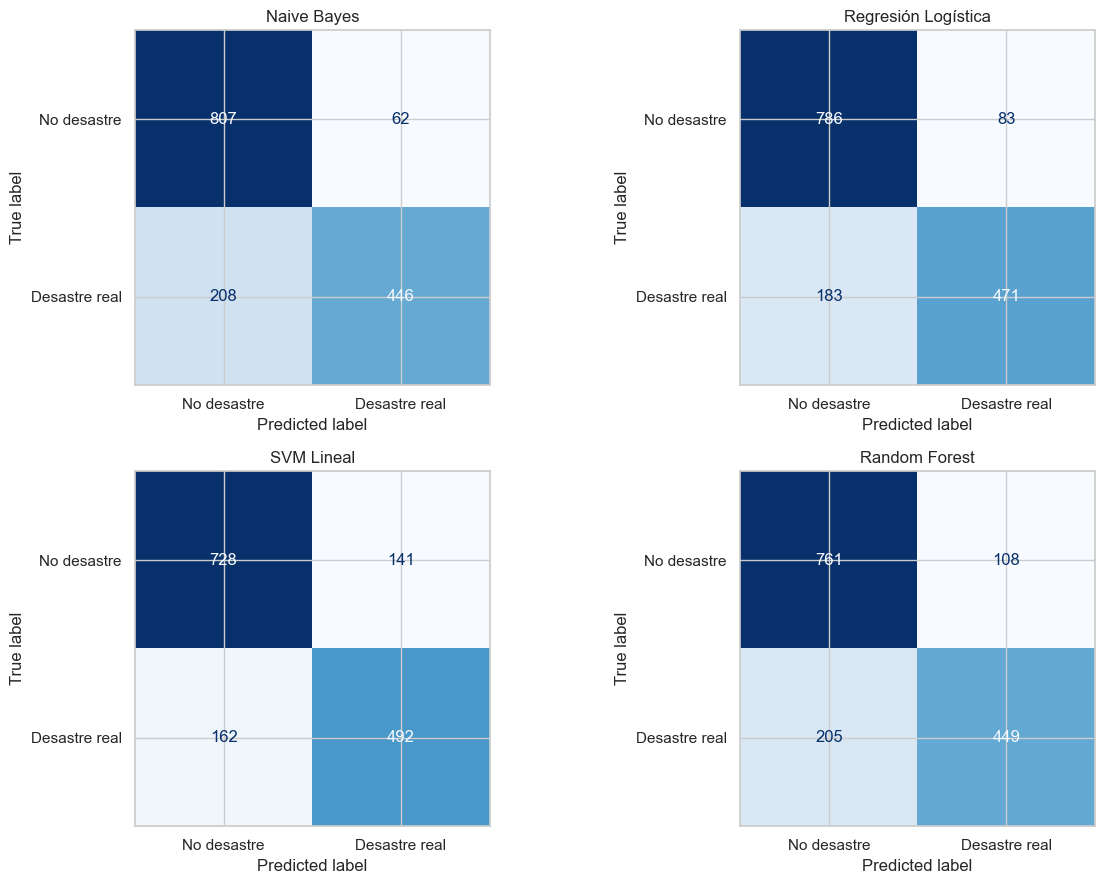

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, (nombre, modelo) in zip(axes.ravel(), modelos_base.items()):
    y_pred = modelo.predict(X_test_tfidf)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=["No desastre", "Desastre real"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(nombre)

plt.tight_layout()
plt.show()

## 5. Ajuste de hiperparámetros del mejor candidato (Punto 6)

Se toma el modelo con mayor F1 base y se hace búsqueda de hiperparámetros con `GridSearchCV`.

In [7]:
# Ajuste de hiperparámetros para Regresión Logística
param_grid_lr = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["lbfgs", "liblinear"],
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    param_grid_lr,
    cv=5,
    scoring="f1",
    n_jobs=-1
)
grid_lr.fit(X_train_tfidf, y_train)

print("Mejores hiperparámetros (Regresión Logística):", grid_lr.best_params_)
print("Mejor F1 en validación cruzada:", round(grid_lr.best_score_, 4))

Mejores hiperparámetros (Regresión Logística): {'C': 1, 'solver': 'lbfgs'}
Mejor F1 en validación cruzada: 0.7305


In [8]:
# Ajuste de hiperparámetros para SVM
param_grid_svm = {
    "C": [0.01, 0.1, 1, 10],
}

grid_svm = GridSearchCV(
    LinearSVC(random_state=RANDOM_STATE, max_iter=2000),
    param_grid_svm,
    cv=5,
    scoring="f1",
    n_jobs=-1
)
grid_svm.fit(X_train_tfidf, y_train)

print("Mejores hiperparámetros (SVM Lineal):", grid_svm.best_params_)
print("Mejor F1 en validación cruzada:", round(grid_svm.best_score_, 4))

Mejores hiperparámetros (SVM Lineal): {'C': 0.1}
Mejor F1 en validación cruzada: 0.7275


## 6. Evaluación final y selección del mejor modelo (Punto 6)

In [9]:
modelos_ajustados = {
    "Naive Bayes": modelos_base["Naive Bayes"],
    "Regresión Logística (ajustada)": grid_lr.best_estimator_,
    "SVM Lineal (ajustado)": grid_svm.best_estimator_,
    "Random Forest": modelos_base["Random Forest"],
}

resultados_finales = []

for nombre, modelo in modelos_ajustados.items():
    y_pred = modelo.predict(X_test_tfidf)
    resultados_finales.append({
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
    })

tabla_final = pd.DataFrame(resultados_finales).set_index("modelo").round(4)
tabla_final.sort_values("f1", ascending=False)

,accuracy,precision,recall,f1
modelo,,,,
Regresión Logística (ajustada),0.8253,0.8502,0.7202,0.7798
SVM Lineal (ajustado),0.8234,0.8545,0.7095,0.7753
Naive Bayes,0.8227,0.8780,0.6820,0.7676
Random Forest,0.7945,0.8061,0.6865,0.7415


In [10]:
# Reporte detallado del mejor modelo
mejor_nombre = tabla_final["f1"].idxmax()
mejor_modelo = modelos_ajustados[mejor_nombre]
y_pred_mejor = mejor_modelo.predict(X_test_tfidf)

print(f"Mejor modelo seleccionado: {mejor_nombre}\n")
print(classification_report(y_test, y_pred_mejor,
                             target_names=["No desastre", "Desastre real"]))

Mejor modelo seleccionado: Regresión Logística (ajustada)

               precision    recall  f1-score   support

  No desastre       0.81      0.90      0.86       869
Desastre real       0.85      0.72      0.78       654

     accuracy                           0.83      1523
    macro avg       0.83      0.81      0.82      1523
 weighted avg       0.83      0.83      0.82      1523



### 6.1 Palabras más influyentes (Regresión Logística)

La Regresión Logística es interpretable: podemos ver qué palabras/bigramas pesan más hacia cada clase.

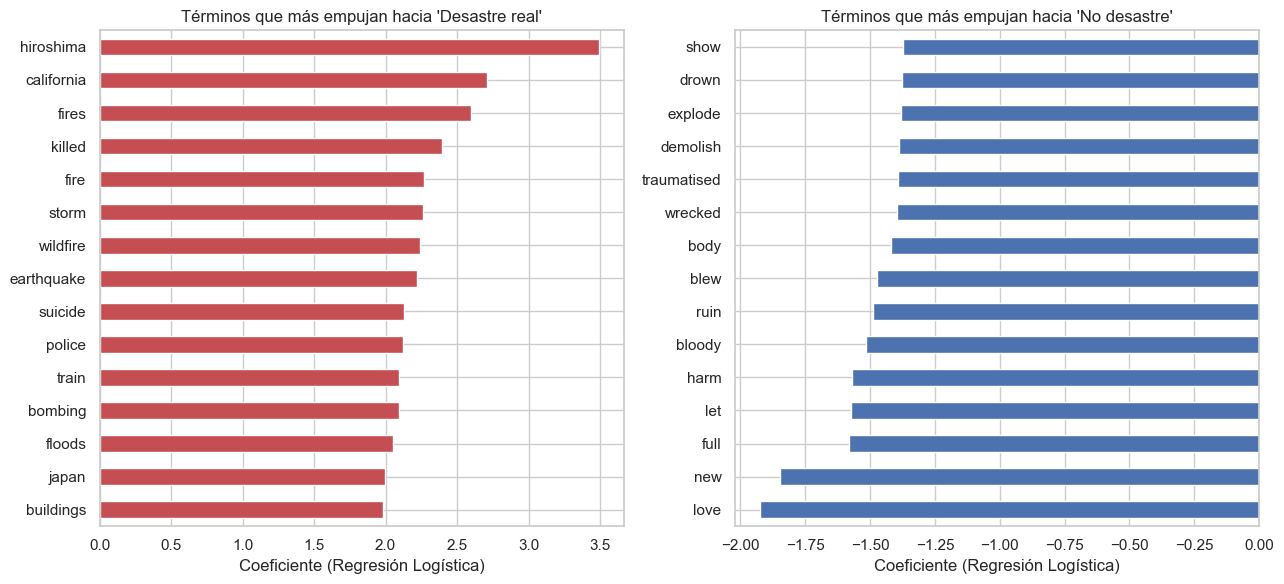

In [11]:
log_reg = grid_lr.best_estimator_
vocabulario = np.array(vectorizador_tfidf.get_feature_names_out())
coeficientes = log_reg.coef_[0]

top_desastre_coef = pd.Series(coeficientes, index=vocabulario).sort_values(ascending=False).head(15)
top_no_desastre_coef = pd.Series(coeficientes, index=vocabulario).sort_values().head(15)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

top_desastre_coef.sort_values().plot(kind="barh", ax=axes[0], color="#C44E52")
axes[0].set_title("Términos que más empujan hacia 'Desastre real'")
axes[0].set_xlabel("Coeficiente (Regresión Logística)")

top_no_desastre_coef.plot(kind="barh", ax=axes[1], color="#4C72B0")
axes[1].set_title("Términos que más empujan hacia 'No desastre'")
axes[1].set_xlabel("Coeficiente (Regresión Logística)")

plt.tight_layout()
plt.show()

## 7. Guardado del modelo y vectorizador

Se guardan el mejor modelo y el vectorizador TF-IDF para ser reutilizados en los notebooks 05 y 06.

In [14]:
joblib.dump(mejor_modelo, "./models/best_model.pkl")
joblib.dump(vectorizador_tfidf, "./models/tfidf_vectorizer.pkl")
print(f"Modelo '{mejor_nombre}' y vectorizador guardados en ./models/")

Modelo 'Regresión Logística (ajustada)' y vectorizador guardados en ./models/


## 8. Resumen

- Se probaron cuatro algoritmos: Naive Bayes, Regresión Logística, SVM Lineal y Random Forest.
- Se ajustaron hiperparámetros de Regresión Logística y SVM con `GridSearchCV` (5-fold cross-validation, métrica F1).
- El mejor modelo se seleccionó por F1-score en el conjunto de prueba.
- Los términos con mayor peso hacia *desastre real* coinciden con los unigramas y bigramas más frecuentes de esa clase, lo que valida la coherencia del preprocesamiento.
- El modelo y el vectorizador quedan guardados para la función de clasificación (notebook 05) y el reentrenamiento con negatividad (notebook 06).